In [1]:
import pandas as pd

df = pd.read_csv("data/insurance.csv")
print(df.shape)
df.head()

(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
df = pd.read_csv("/Users/eshalasad/Documents/insurance-cost-analysis/data/insurance.csv")

In [3]:
print(df.shape)
df.head()

(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


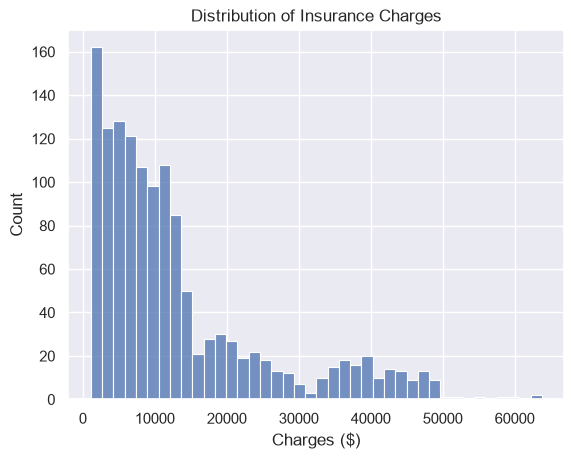

In [7]:
sns.histplot(df["charges"], bins=40)
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges ($)")
plt.show()

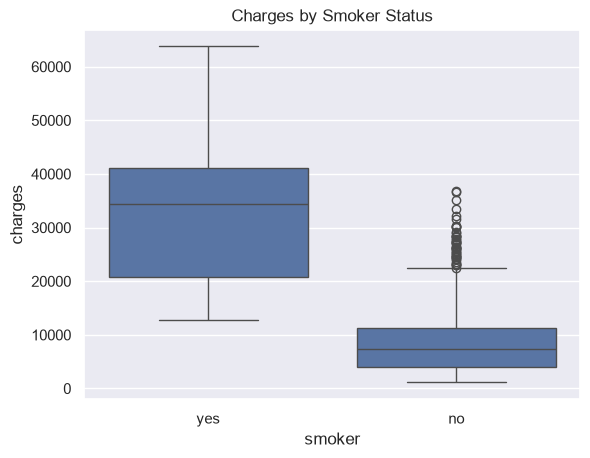

smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

In [8]:
sns.boxplot(data=df, x="smoker", y="charges")
plt.title("Charges by Smoker Status")
plt.show()

df.groupby("smoker")["charges"].mean()

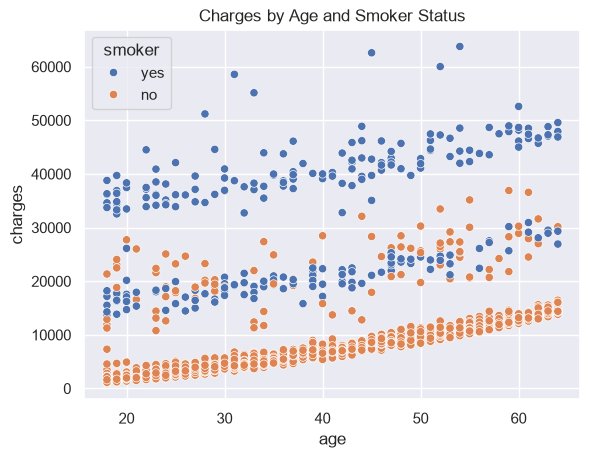

In [9]:
sns.scatterplot(data=df, x="age", y="charges", hue="smoker")
plt.title("Charges by Age and Smoker Status")
plt.show()

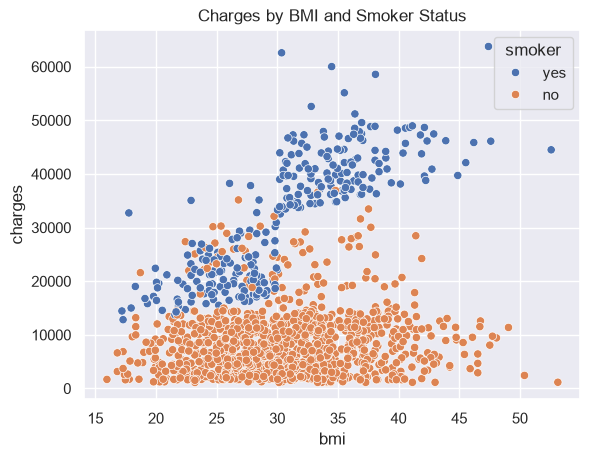

In [10]:
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker")
plt.title("Charges by BMI and Smoker Status")
plt.show()

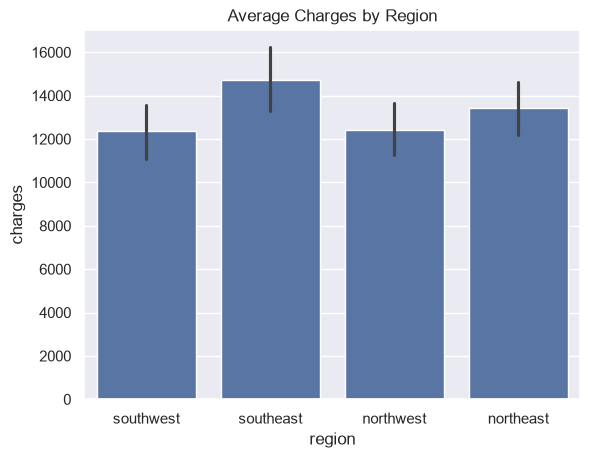

In [11]:
sns.barplot(data=df, x="region", y="charges")
plt.title("Average Charges by Region")
plt.show()

In [12]:
import sqlite3

conn = sqlite3.connect(":memory:")
df.to_sql("insurance", conn, index=False)

1338

In [13]:
query = """
SELECT smoker, COUNT(*) AS people, ROUND(AVG(charges), 2) AS avg_charges
FROM insurance
GROUP BY smoker;
"""
pd.read_sql(query, conn)

,smoker,people,avg_charges
0,no,1064,8434.27
1,yes,274,32050.23


In [21]:
query = """
SELECT region, smoker, ROUND(AVG(charges), 2) AS avg_charges
FROM insurance
GROUP BY region, smoker
ORDER BY avg_charges DESC;
"""
pd.read_sql(query, conn)

,region,smoker,avg_charges
0,southeast,yes,34845.00
1,southwest,yes,32269.06
2,northwest,yes,30192.00
3,northeast,yes,29673.54
4,northeast,no,9165.53
5,northwest,no,8556.46
6,southeast,no,8032.22
7,southwest,no,8019.28


In [15]:
query = """
SELECT
  CASE
    WHEN age < 30 THEN '18-29'
    WHEN age < 45 THEN '30-44'
    WHEN age < 60 THEN '45-59'
    ELSE '60+'
  END AS age_group,
  COUNT(*) AS people,
  ROUND(AVG(charges), 2) AS avg_charges
FROM insurance
GROUP BY age_group
ORDER BY age_group;
"""
pd.read_sql(query, conn)

,age_group,people,avg_charges
0,18-29,417,9182.49
1,30-44,392,12490.91
2,45-59,415,15922.93
3,60+,114,21248.02


In [16]:
query = """
SELECT
  CASE WHEN bmi >= 30 THEN 'BMI 30+' ELSE 'BMI under 30' END AS bmi_group,
  smoker,
  COUNT(*) AS people,
  ROUND(AVG(charges), 2) AS avg_charges
FROM insurance
GROUP BY bmi_group, smoker
ORDER BY avg_charges DESC;
"""
pd.read_sql(query, conn)

,bmi_group,smoker,people,avg_charges
0,BMI 30+,yes,145,41557.99
1,BMI under 30,yes,129,21363.22
2,BMI 30+,no,562,8842.69
3,BMI under 30,no,502,7977.03


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

X = pd.get_dummies(df.drop(columns="charges"), drop_first=True)
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)

print("R²:", round(r2_score(y_test, pred), 3))
print("Avg error: $", round(mean_absolute_error(y_test, pred), 2))

pd.Series(model.coef_, index=X.columns).round(2).sort_values()

R²: 0.784
Avg error: $ 4181.19


region_southwest     -809.80
region_southeast     -657.86
region_northwest     -370.68
sex_male              -18.59
age                   256.98
bmi                   337.09
children              425.28
smoker_yes          23651.13
dtype: float64

In [19]:
df2 = df.copy()
df2["obese_smoker"] = ((df2["bmi"] >= 30) & (df2["smoker"] == "yes")).astype(int)
df2["age_sq"] = df2["age"] ** 2

X2 = pd.get_dummies(df2.drop(columns="charges"), drop_first=True)
X2_train, X2_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X2_train, y_train)
pred2 = model2.predict(X2_test)

print("R²:", round(r2_score(y_test, pred2), 3))
print("Avg error: $", round(mean_absolute_error(y_test, pred2), 2))

pd.Series(model2.coef_, index=X2.columns).round(2).sort_values()

R²: 0.876
Avg error: $ 2420.47


region_southwest    -1326.49
region_southeast     -676.73
sex_male             -502.14
region_northwest     -334.12
age_sq                  3.22
age                     6.59
bmi                    50.50
children              603.13
smoker_yes          13319.42
obese_smoker        19785.80
dtype: float64